# Klein VAE Experiments

In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
root = rootutils.setup_root(search_from=".", indicator=".project-root", pythonpath=True, cwd=True)

In [2]:
import pandas as pd

In [140]:
from src.data.uniform_filters_datamodule import UniformFiltersDataModule
from src.models.klein_vae_module import KleinVAEModule
from src.models.components.vae import SimpleVAE, ConvolutionalVAE

from src.data.components.utils import generate_klein_filter_matrix
from src.utils import project_to_klein

import matplotlib.pyplot as plt

from lightning.pytorch.trainer import Trainer
import torch

import random
import numpy as np
import pandas as pd

from ripser import ripser
from persim import plot_diagrams


/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/persim/landscapes/visuals.py:310: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ls[:, 0], ls[:, 1], label=f"$\lambda_{{{depth}}}$", alpha=alpha)
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/persim/landscapes/visuals.py:469: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(domain, l, label=f"$\lambda_{{{depth}}}$", alpha=alpha)


In [175]:
BATCH_SIZE = 64

Total training examples: 8000


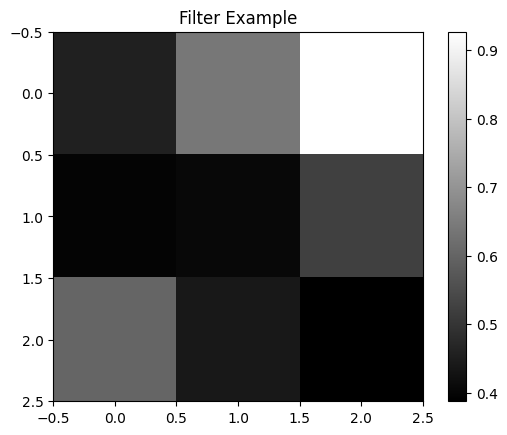

In [176]:
datamodule = UniformFiltersDataModule(num_samples_per_angle=100, batch_size=BATCH_SIZE)
datamodule.setup()
filter_example = datamodule.train_dataloader().dataset[0][0].reshape(3,3)

train_loader = datamodule.train_dataloader()
total_examples = len(train_loader.dataset)
print(f"Total training examples: {total_examples}")

plt.imshow(filter_example, cmap='gray')
plt.colorbar()
plt.title('Filter Example')
plt.show()

### Testing that samples from `UniformFiltersDataModule` lie on the Klein bottle

In [148]:
dataset = datamodule.train_dataloader().dataset
indices = random.sample(range(len(dataset)), 500)
batch = np.array([dataset[i][0].numpy() for i in indices])

In [149]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_82822/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_82822/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


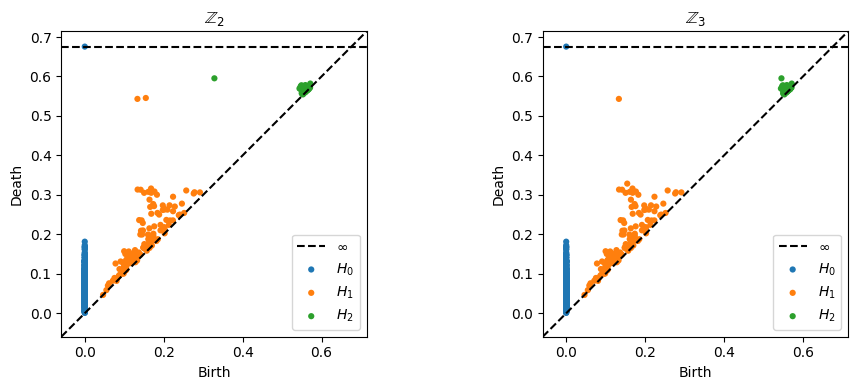

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Running the model

In [177]:
from src.models.components.vae import SimpleVAE
from src.models.klein_vae_module import KleinVAEModule

vae_model = SimpleVAE(hidden_dims=[16,16])
klein_vae_module = KleinVAEModule(model=vae_model, batch_size=BATCH_SIZE, lr=1e-3, kl_weight=0, sigma2=10)

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


#### Checking the filters BEFORE training

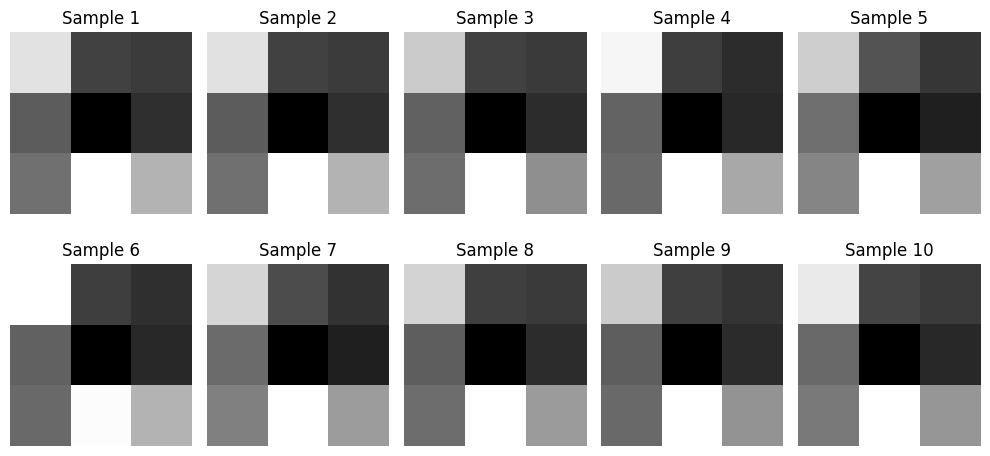

In [8]:
samples = klein_vae_module.sample(num_samples=10)
filters_from_decoder = klein_vae_module.model.decode(samples).reshape(-1, 3, 3)

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

In [9]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.model.decode(samples).detach().cpu().numpy()
batch = decoded

diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Decoded Filters')

NameError: name 'ripser' is not defined

### Training

In [178]:
trainer = Trainer(accelerator="cpu", max_epochs=300, enable_progress_bar=True)
trainer.fit(klein_vae_module, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SimpleVAE | 874    | train
--------------------------------------------
874       Trainable params
0         Non-trainable params
874       Total params
0.003     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode


/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 299: 100%|██████████| 125/125 [00:02<00:00, 44.71it/s, v_num=89, train_loss=0.647, recon_loss=0.647, kl_div=17.40] 

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 125/125 [00:02<00:00, 44.53it/s, v_num=89, train_loss=0.647, recon_loss=0.647, kl_div=17.40]


In [179]:
# Retrieve and display the logged metrics after training
metrics = trainer.callback_metrics
print(metrics)

{'train_loss': tensor(0.6466), 'recon_loss': tensor(0.6466), 'kl_div': tensor(17.4220), 'val_loss': tensor(0.6432), 'val_recon_loss': tensor(0.6432), 'val_kl_div': tensor(17.4221)}


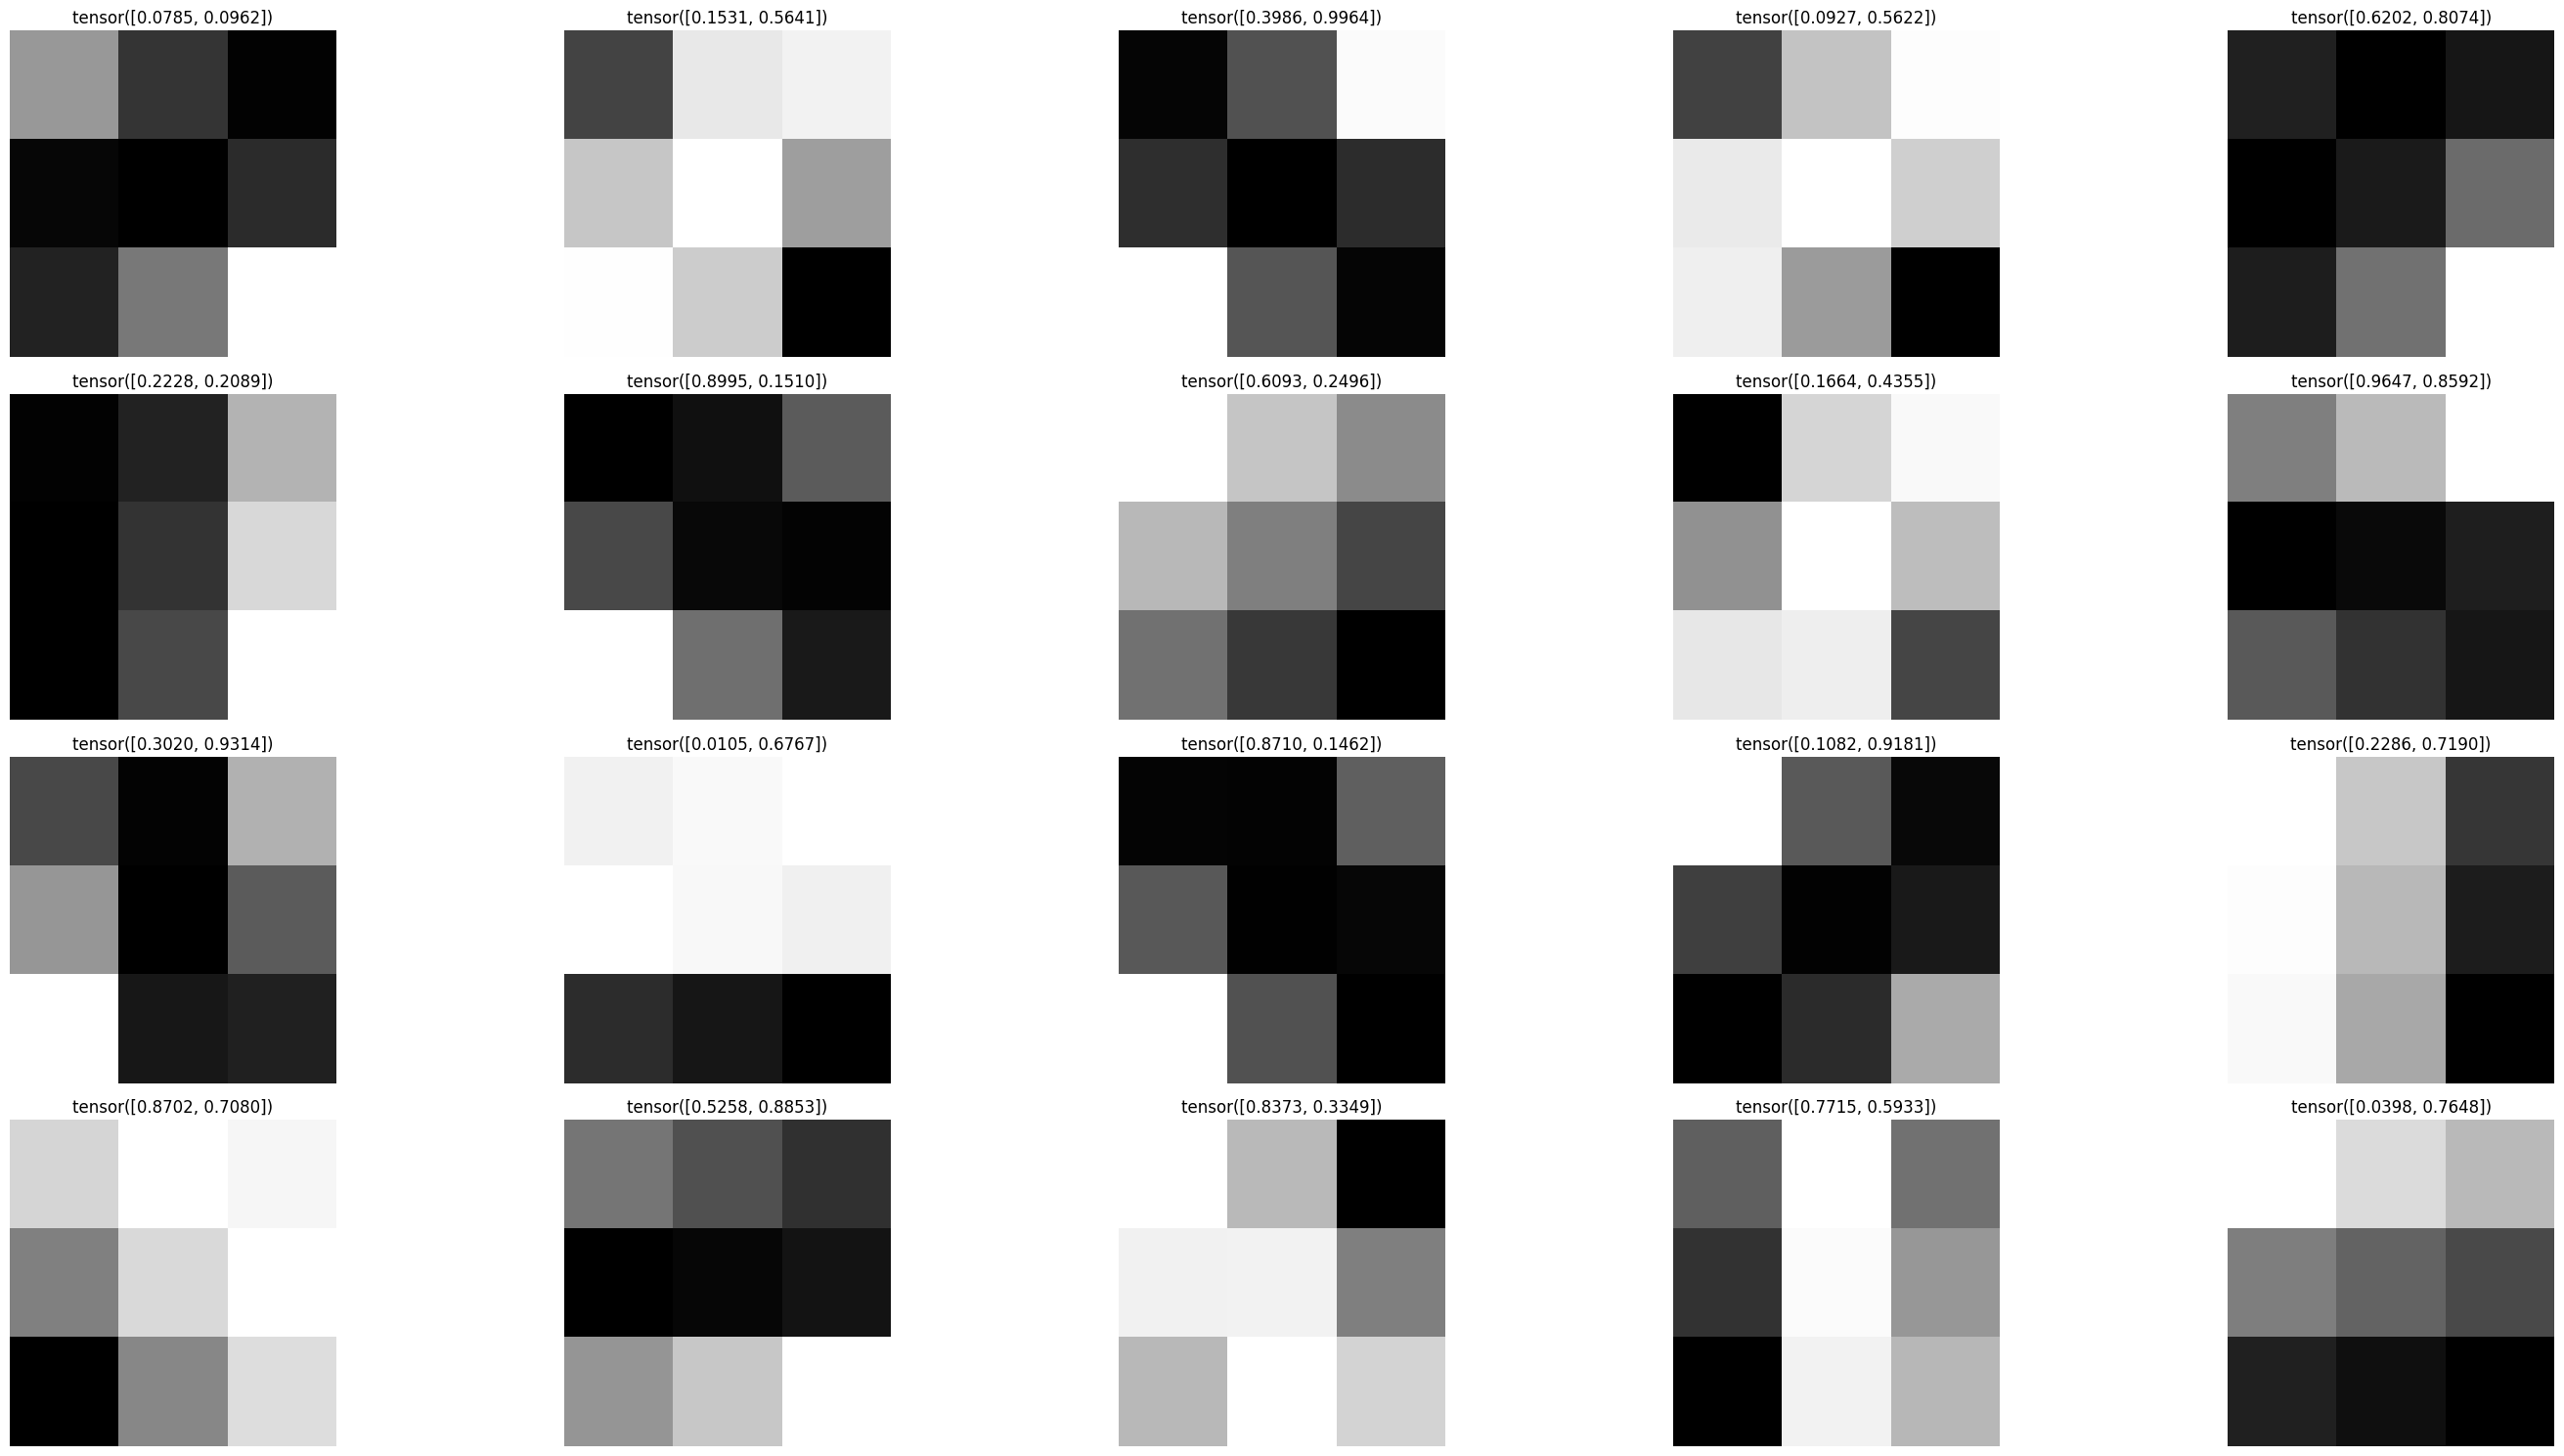

In [180]:
samples = klein_vae_module.sample(num_samples=20)
filters_from_decoder = klein_vae_module.decode(samples).reshape(-1,3,3)


plt.figure(figsize=(30, 15))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(4, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'{samples[i]}')
plt.tight_layout()
plt.show()

### Testing that decoded samples also lie on the Klein bottle

In [81]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.model.decode(samples)
batch = decoded.detach().cpu().numpy()

In [127]:
diagrams2 = ripser(batch, maxdim=2, coeff=2)['dgms']
diagrams3 = ripser(batch, maxdim=2, coeff=3)['dgms']

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_66853/207474767.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_66853/207474767.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


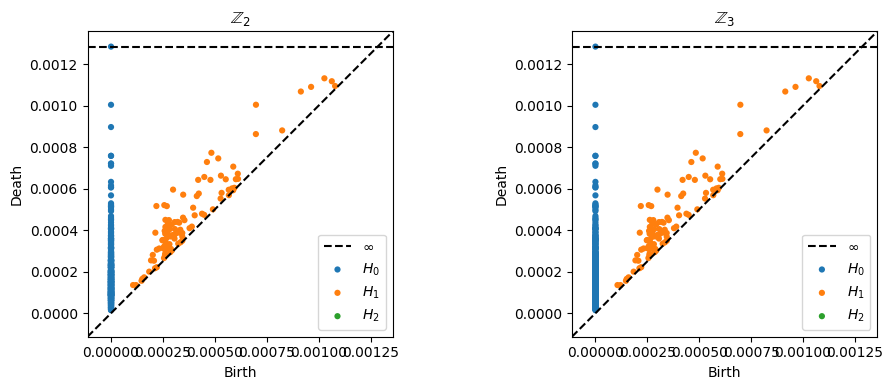

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

### Try to find the problem

In [181]:
n_points = 20

grid_on_flat_klein = torch.cartesian_prod(torch.linspace(0, 1, n_points), 
                                          torch.linspace(0, 1, n_points))
filters = torch.stack([generate_klein_filter_matrix(theta_1 * 2 * torch.pi, theta_2 * 2 * torch.pi, size=3, midpoint=False).flatten() 
                        for theta_1, theta_2 in grid_on_flat_klein])

In [182]:
mu_on_klein = project_to_klein(klein_vae_module.model.encode(filters)[0])
sigma_on_klein = klein_vae_module.model.encode(filters)[1]

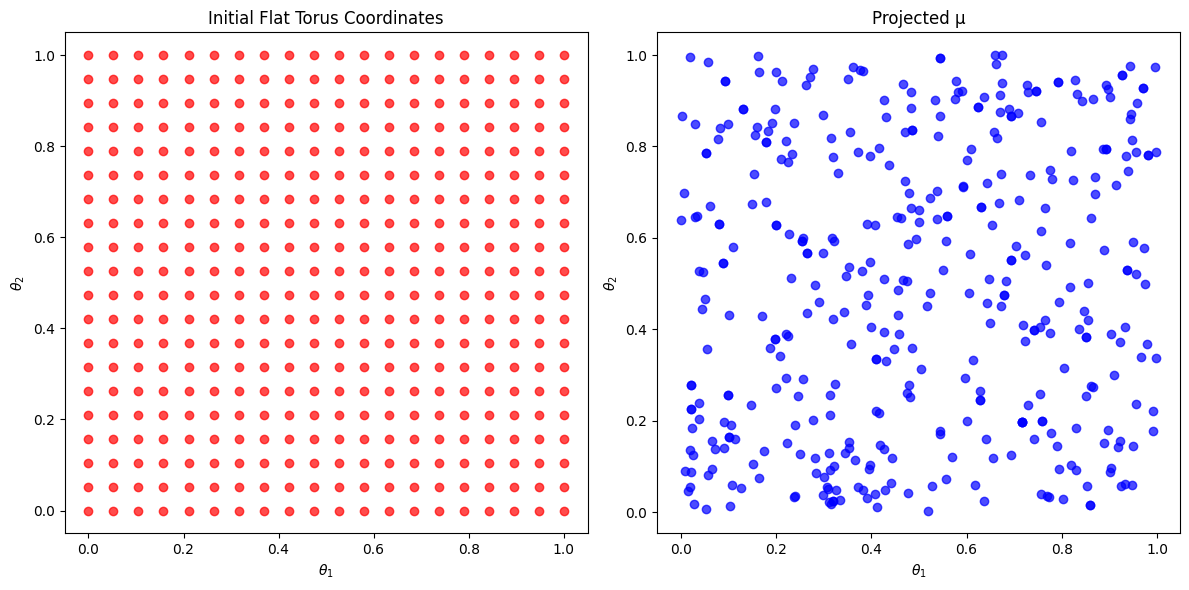

In [183]:
# scatter plot of initial grid coordinates vs. projected μ on the Klein bottle
initial_coords = grid_on_flat_klein.cpu().numpy()
klein_coords = mu_on_klein.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#axes[0].scatter(datamodule.coordinates[:, 0], datamodule.coordinates[:, 1], c='green', alpha=0.5, label='Uniform Samples')
#axes[0].legend()

axes[0].scatter(initial_coords[:, 0], initial_coords[:, 1], c='red', alpha=0.7)
axes[0].set_xlabel(r'$\theta_1$')
axes[0].set_ylabel(r'$\theta_2$')
axes[0].set_title('Initial Flat Torus Coordinates')

axes[1].scatter(klein_coords[:, 0], klein_coords[:, 1], c='blue', alpha=0.7)

axes[1].set_xlabel(r'$\theta_1$')
axes[1].set_ylabel(r'$\theta_2$')
axes[1].set_title('Projected μ')

plt.tight_layout()
plt.show()

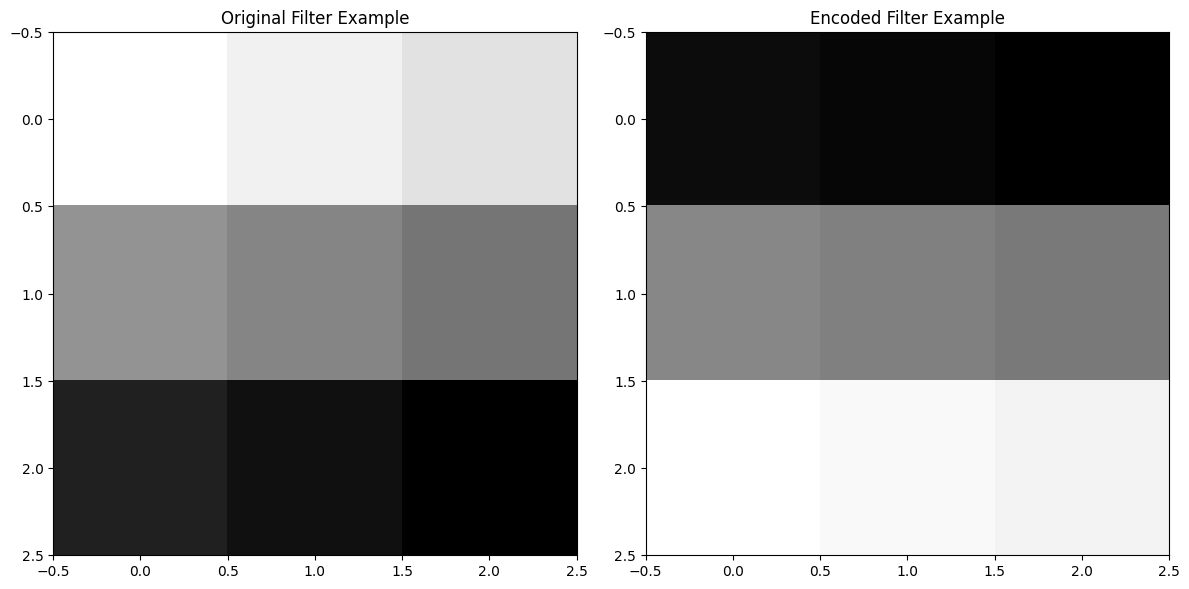

In [186]:
filter_example = datamodule.train_dataloader().dataset[200][0].reshape(3,3)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(filter_example, cmap='gray')
encoded_example = klein_vae_module.encode(filter_example.flatten())
encoded_filter = klein_vae_module.decode(encoded_example[0].unsqueeze(0))
axes[1].imshow(encoded_filter.reshape(3, 3).detach().cpu().numpy(), cmap='gray')
axes[0].set_title('Original Filter Example')
axes[1].set_title('Encoded Filter Example')
plt.tight_layout()
plt.show()

In [187]:
filter_example, encoded_filter.reshape(3,3)

(tensor([[0.6658, 0.6465, 0.6269],
         [0.5236, 0.5028, 0.4817],
         [0.3706, 0.3482, 0.3257]]),
 tensor([[0.3571, 0.3492, 0.3412],
         [0.5083, 0.5004, 0.4926],
         [0.6577, 0.6500, 0.6422]], grad_fn=<ViewBackward0>))

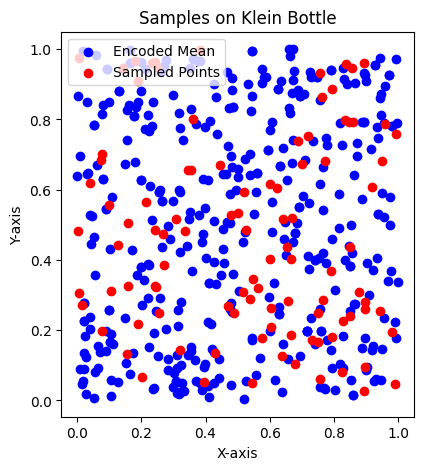

In [188]:
samples_on_klein, samples_from_model = klein_vae_module.sample(num_samples=100, return_unprojected=True)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(mu_on_klein[:, 0].detach().cpu().numpy(), mu_on_klein[:, 1].detach().cpu().numpy(), c='blue', label='Encoded Mean')
plt.scatter(samples_on_klein[:, 0].detach().cpu().numpy(), samples_on_klein[:, 1].detach().cpu().numpy(), c='red', label='Sampled Points')
plt.title('Samples on Klein Bottle')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()

## VIsualising logs

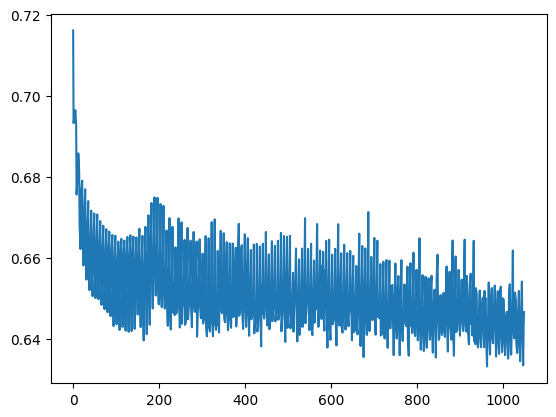

In [189]:
logs_dir = trainer.logger.log_dir

logs_df = pd.read_csv(f"{logs_dir}/metrics.csv")

plt.plot(logs_df['recon_loss'].dropna())